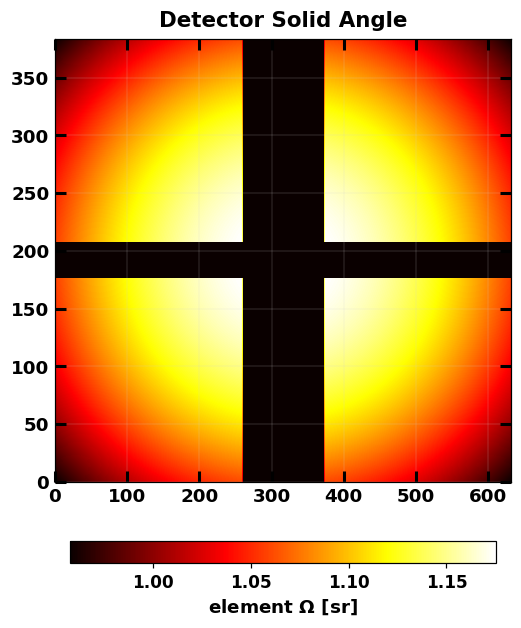

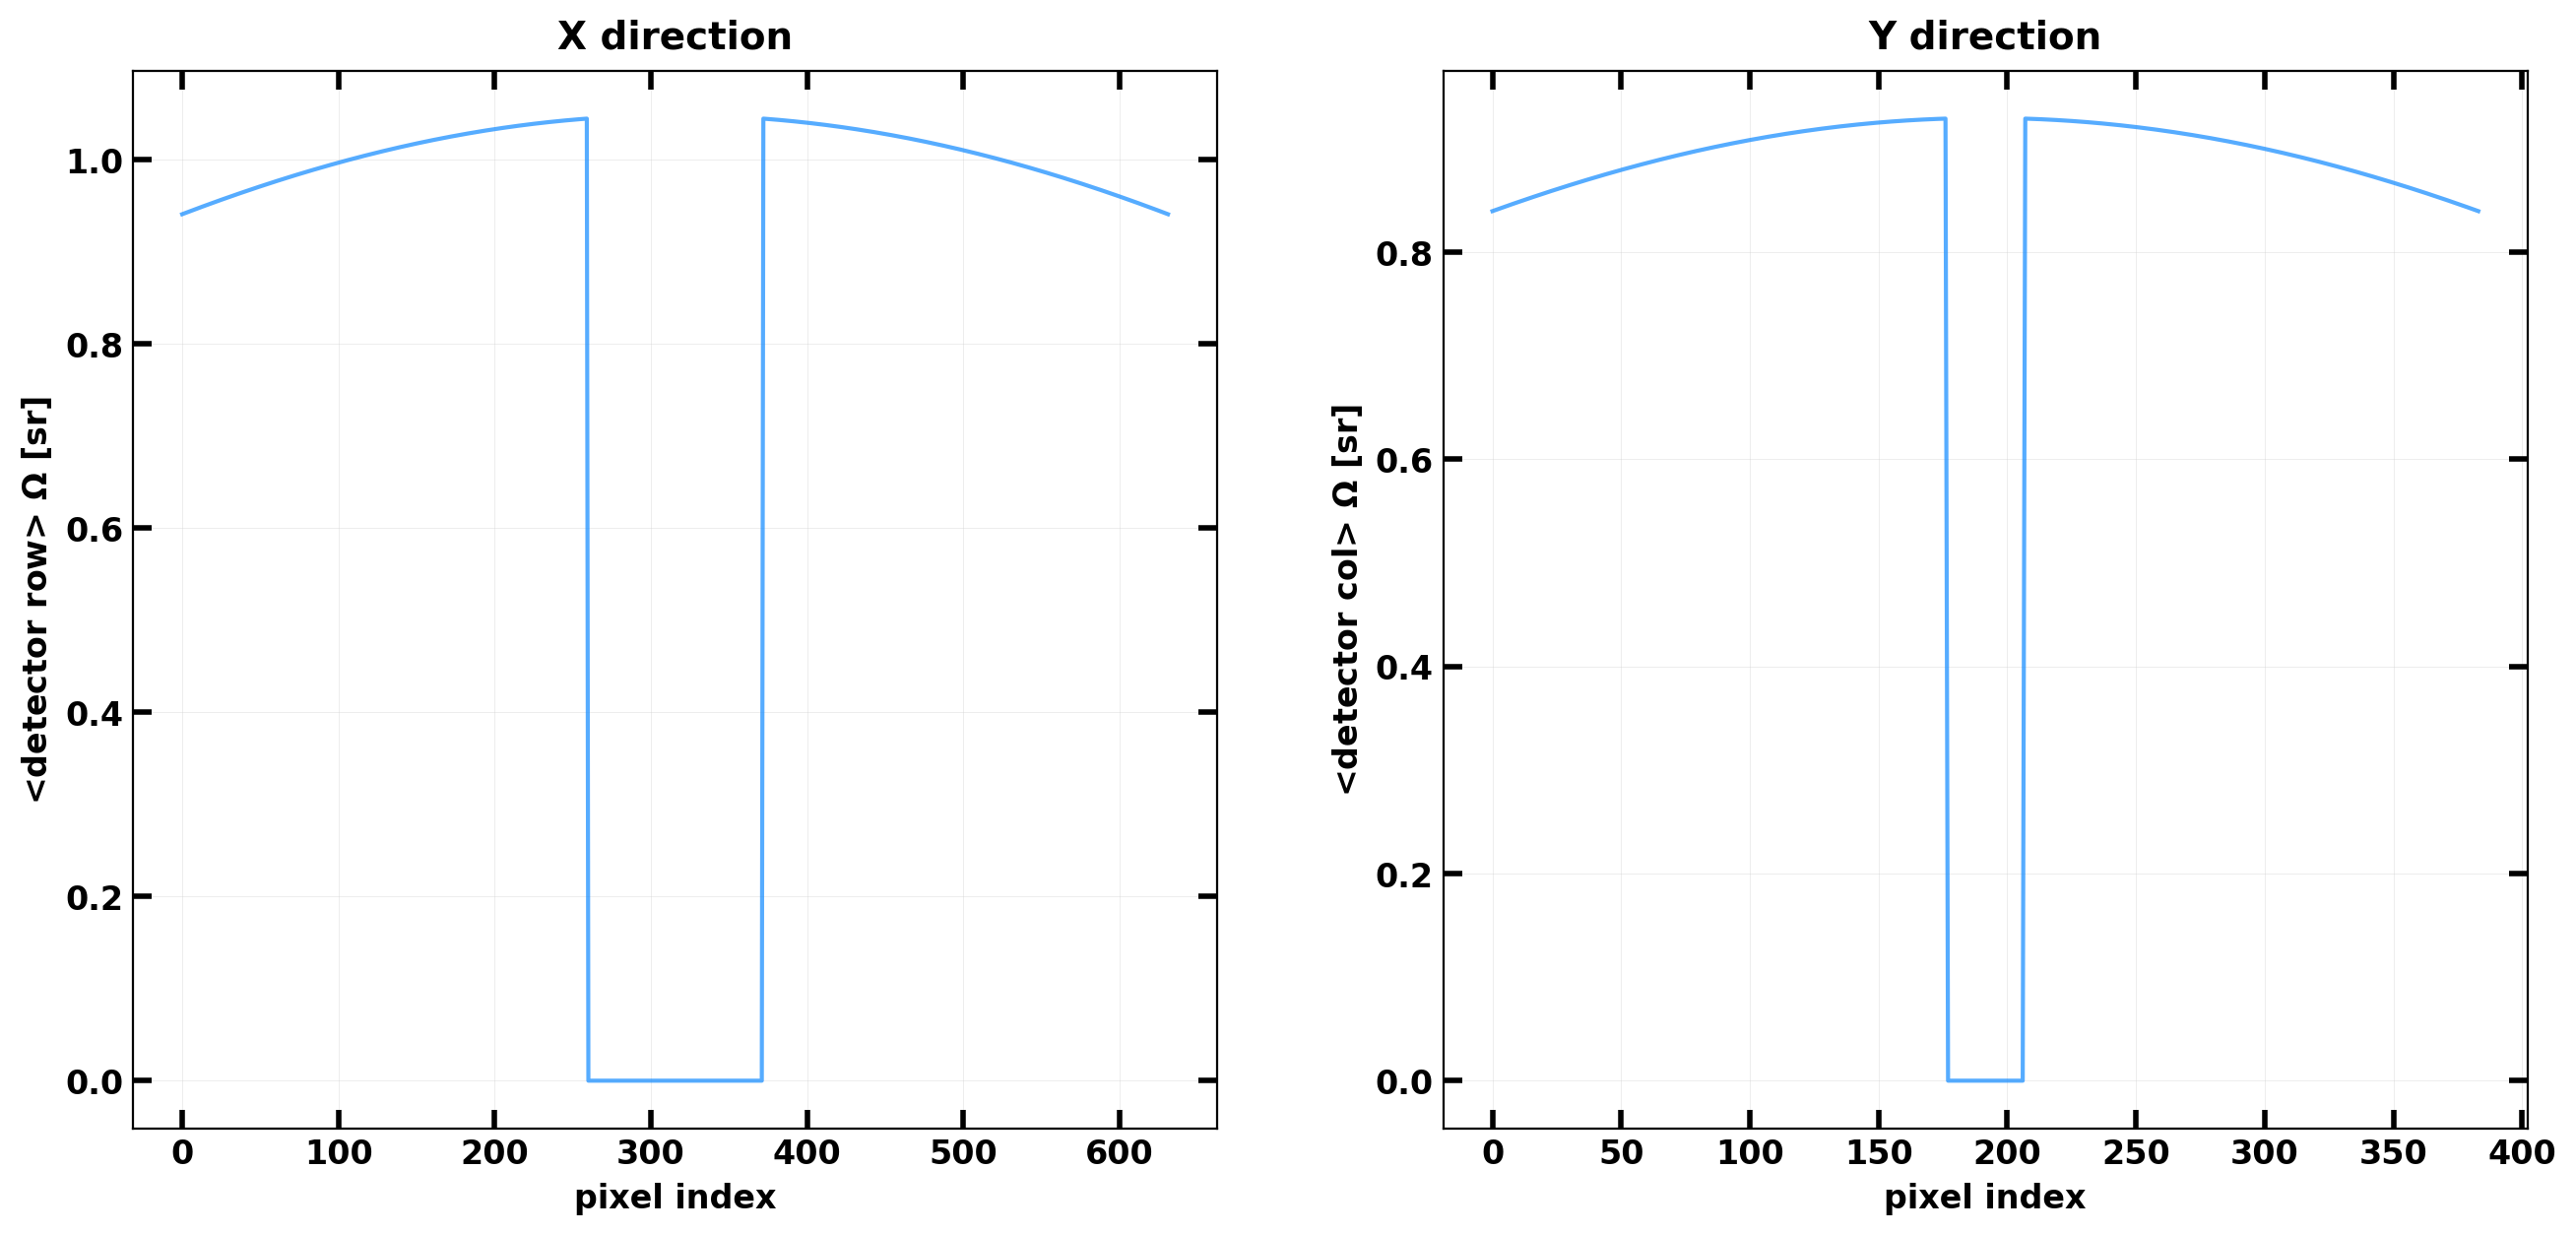

In [1]:
import numpy as np

from bloodmoon.mask import codedmask
import darksun as ds

from var import detector_solid_angle


#basepath = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
#maskpath = f'{basepath}/wfm_mask_summer2021.fits'
#datapath = f'{basepath}/IROSDummy/CXB_infdet_2-50keV_1ks_cam1a_detected.fits'

basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'
datapath = f'{basepath}/IROSDummy/catalog_withCXB_1Crab_infdet_2-50keV_1ks/cam1a/catalog_withCXB_1Crab_infdet_2-50keV_1ks_cam1a_detected.fits'
#datapath = f'{basepath}/IROSDummy/CXB_1ks_detected_2-50keV'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)

Omega = detector_solid_angle(wfm)

ds.image_plot(
    dmaps=ds.map4image(
        img=Omega,
        title='Detector Solid Angle',
        cbarlabel=r'element $\Omega$ [sr]',
        cbarloc='bottom',
        img_kwargs={
            'cmap': 'hot',
            'vmin': np.unique(Omega)[1],
            'aspect': ASPECT,
        },
    ),
)

# Omega profiles along X and Y axes
r, s = wfm.shape_detector
collapsed_omega_x = Omega.sum(axis=0) / r
collapsed_omega_y = Omega.sum(axis=1) / s

dmapx_omega = ds.map4plot(
    arrs=collapsed_omega_x,
    title='X direction',
    ylabel=r'<detector row> $\Omega$ [sr]',
    xlabel='pixel index',
    #labels=('detector', 'smoothed'),
    color=('DodgerBlue')
)
dmapy_omega = ds.map4plot(
    arrs=collapsed_omega_y,
    title='Y direction',
    ylabel=r'<detector col> $\Omega$ [sr]',
    xlabel='pixel index',
    #labels=('detector', 'smoothed'),
    color=('DodgerBlue')
)
ds.plot(dmaps=(dmapx_omega, dmapy_omega), ncols=2)

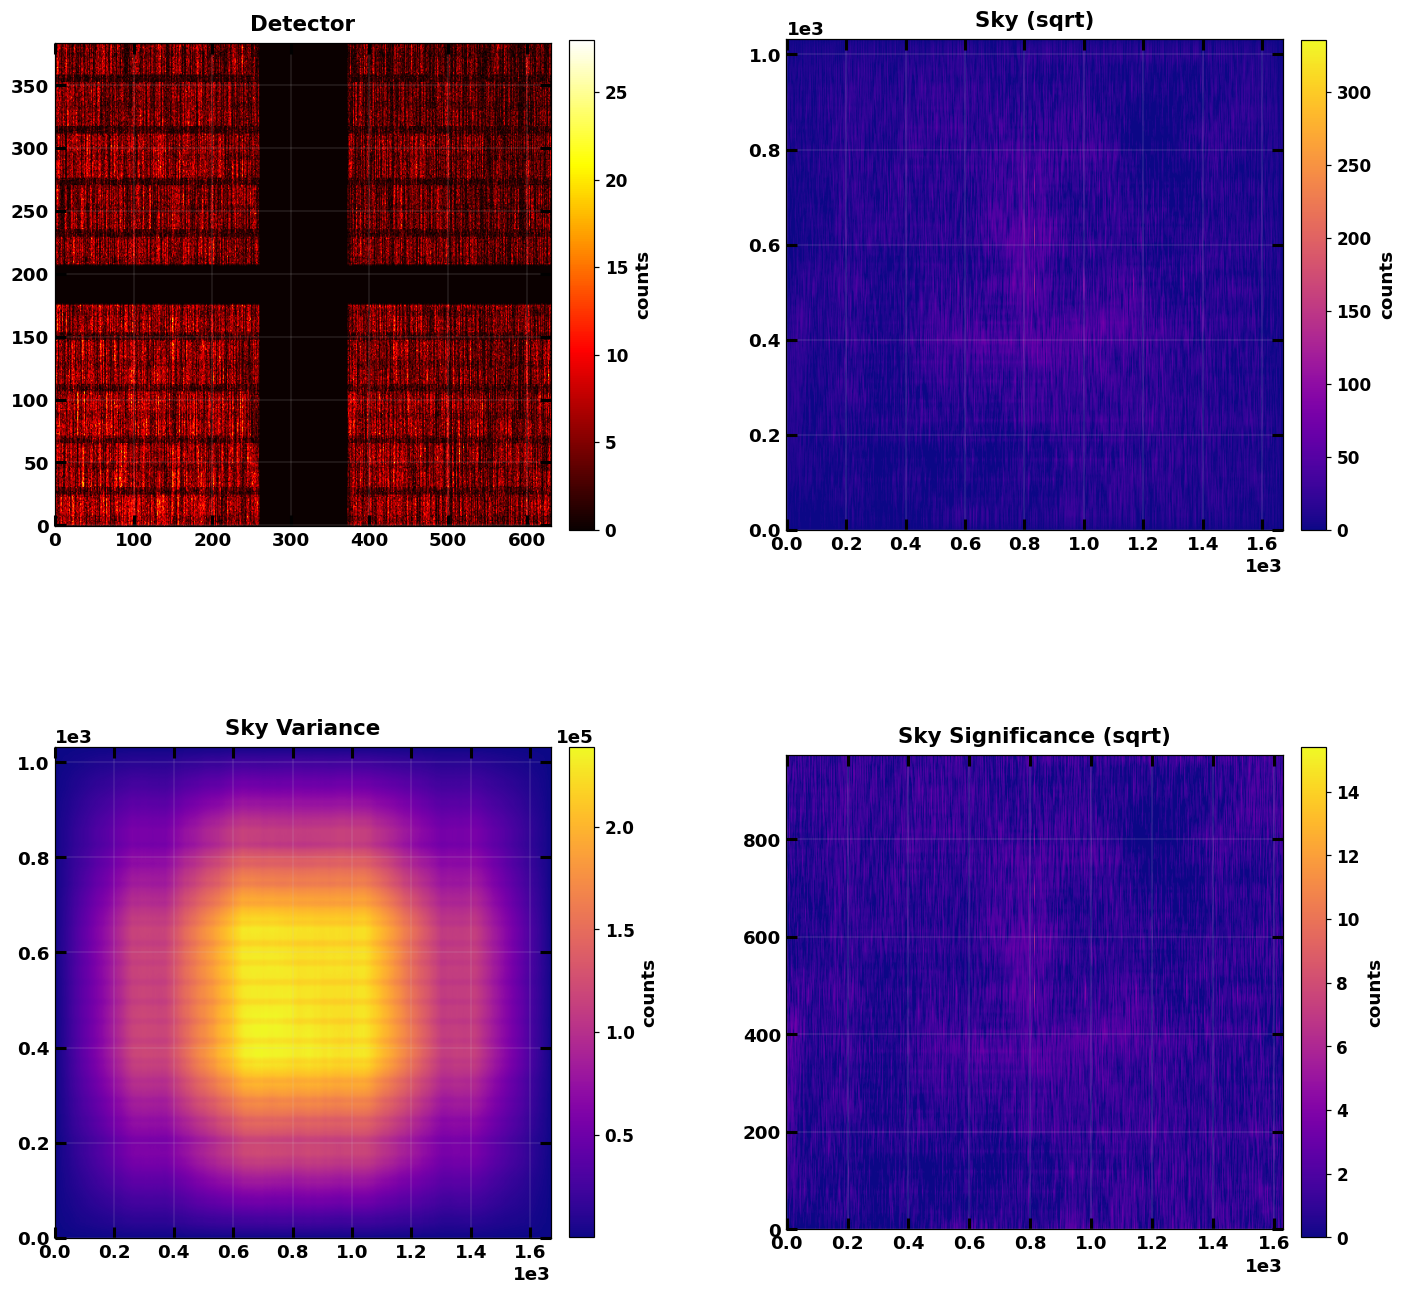

In [2]:
import numpy as np

from bloodmoon.mask import codedmask, count, decode, variance

import darksun as ds

from var import sky_variance, sky_significance

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
sdl = ds.get_data(datapath)

detector = count(wfm, sdl.DLdata)[0]
sky = decode(wfm, detector)
varmap = sky_variance(wfm, detector)

YLIM, XLIM = 30 * UPY, 20 * UPX
significance = sky_significance(sky, varmap, ycut=YLIM, xcut=XLIM)


ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
kw = {
    'cmap': 'plasma',
    'aspect': ASPECT,
}
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title='Detector',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=np.sqrt(np.clip(sky, a_min=0, a_max=None)),
            title='Sky (sqrt)',
            cbarlabel='counts',
            img_kwargs=kw,
        ),
        ds.map4image(
            img=varmap,
            title='Sky Variance',
            cbarlabel='counts',
            img_kwargs=kw,
        ),
        ds.map4image(
            img=np.sqrt(np.clip(significance, a_min=0, a_max=None)),
            title='Sky Significance (sqrt)',
            cbarlabel='counts',
            img_kwargs=kw,
        ),
    ),
    ncols=2,
    nrows=2,
)

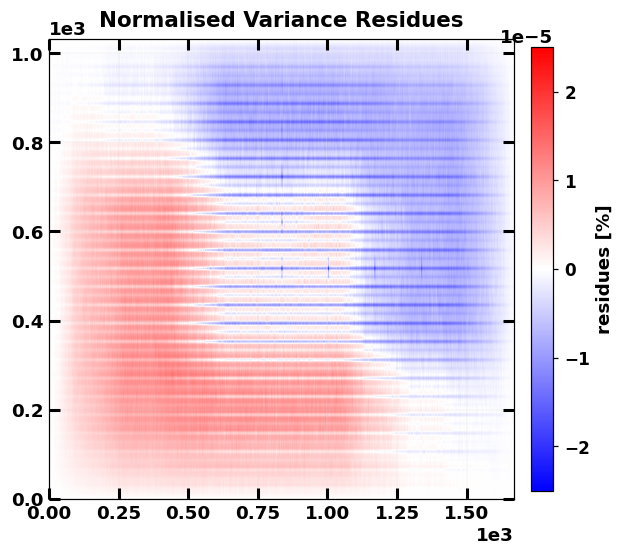

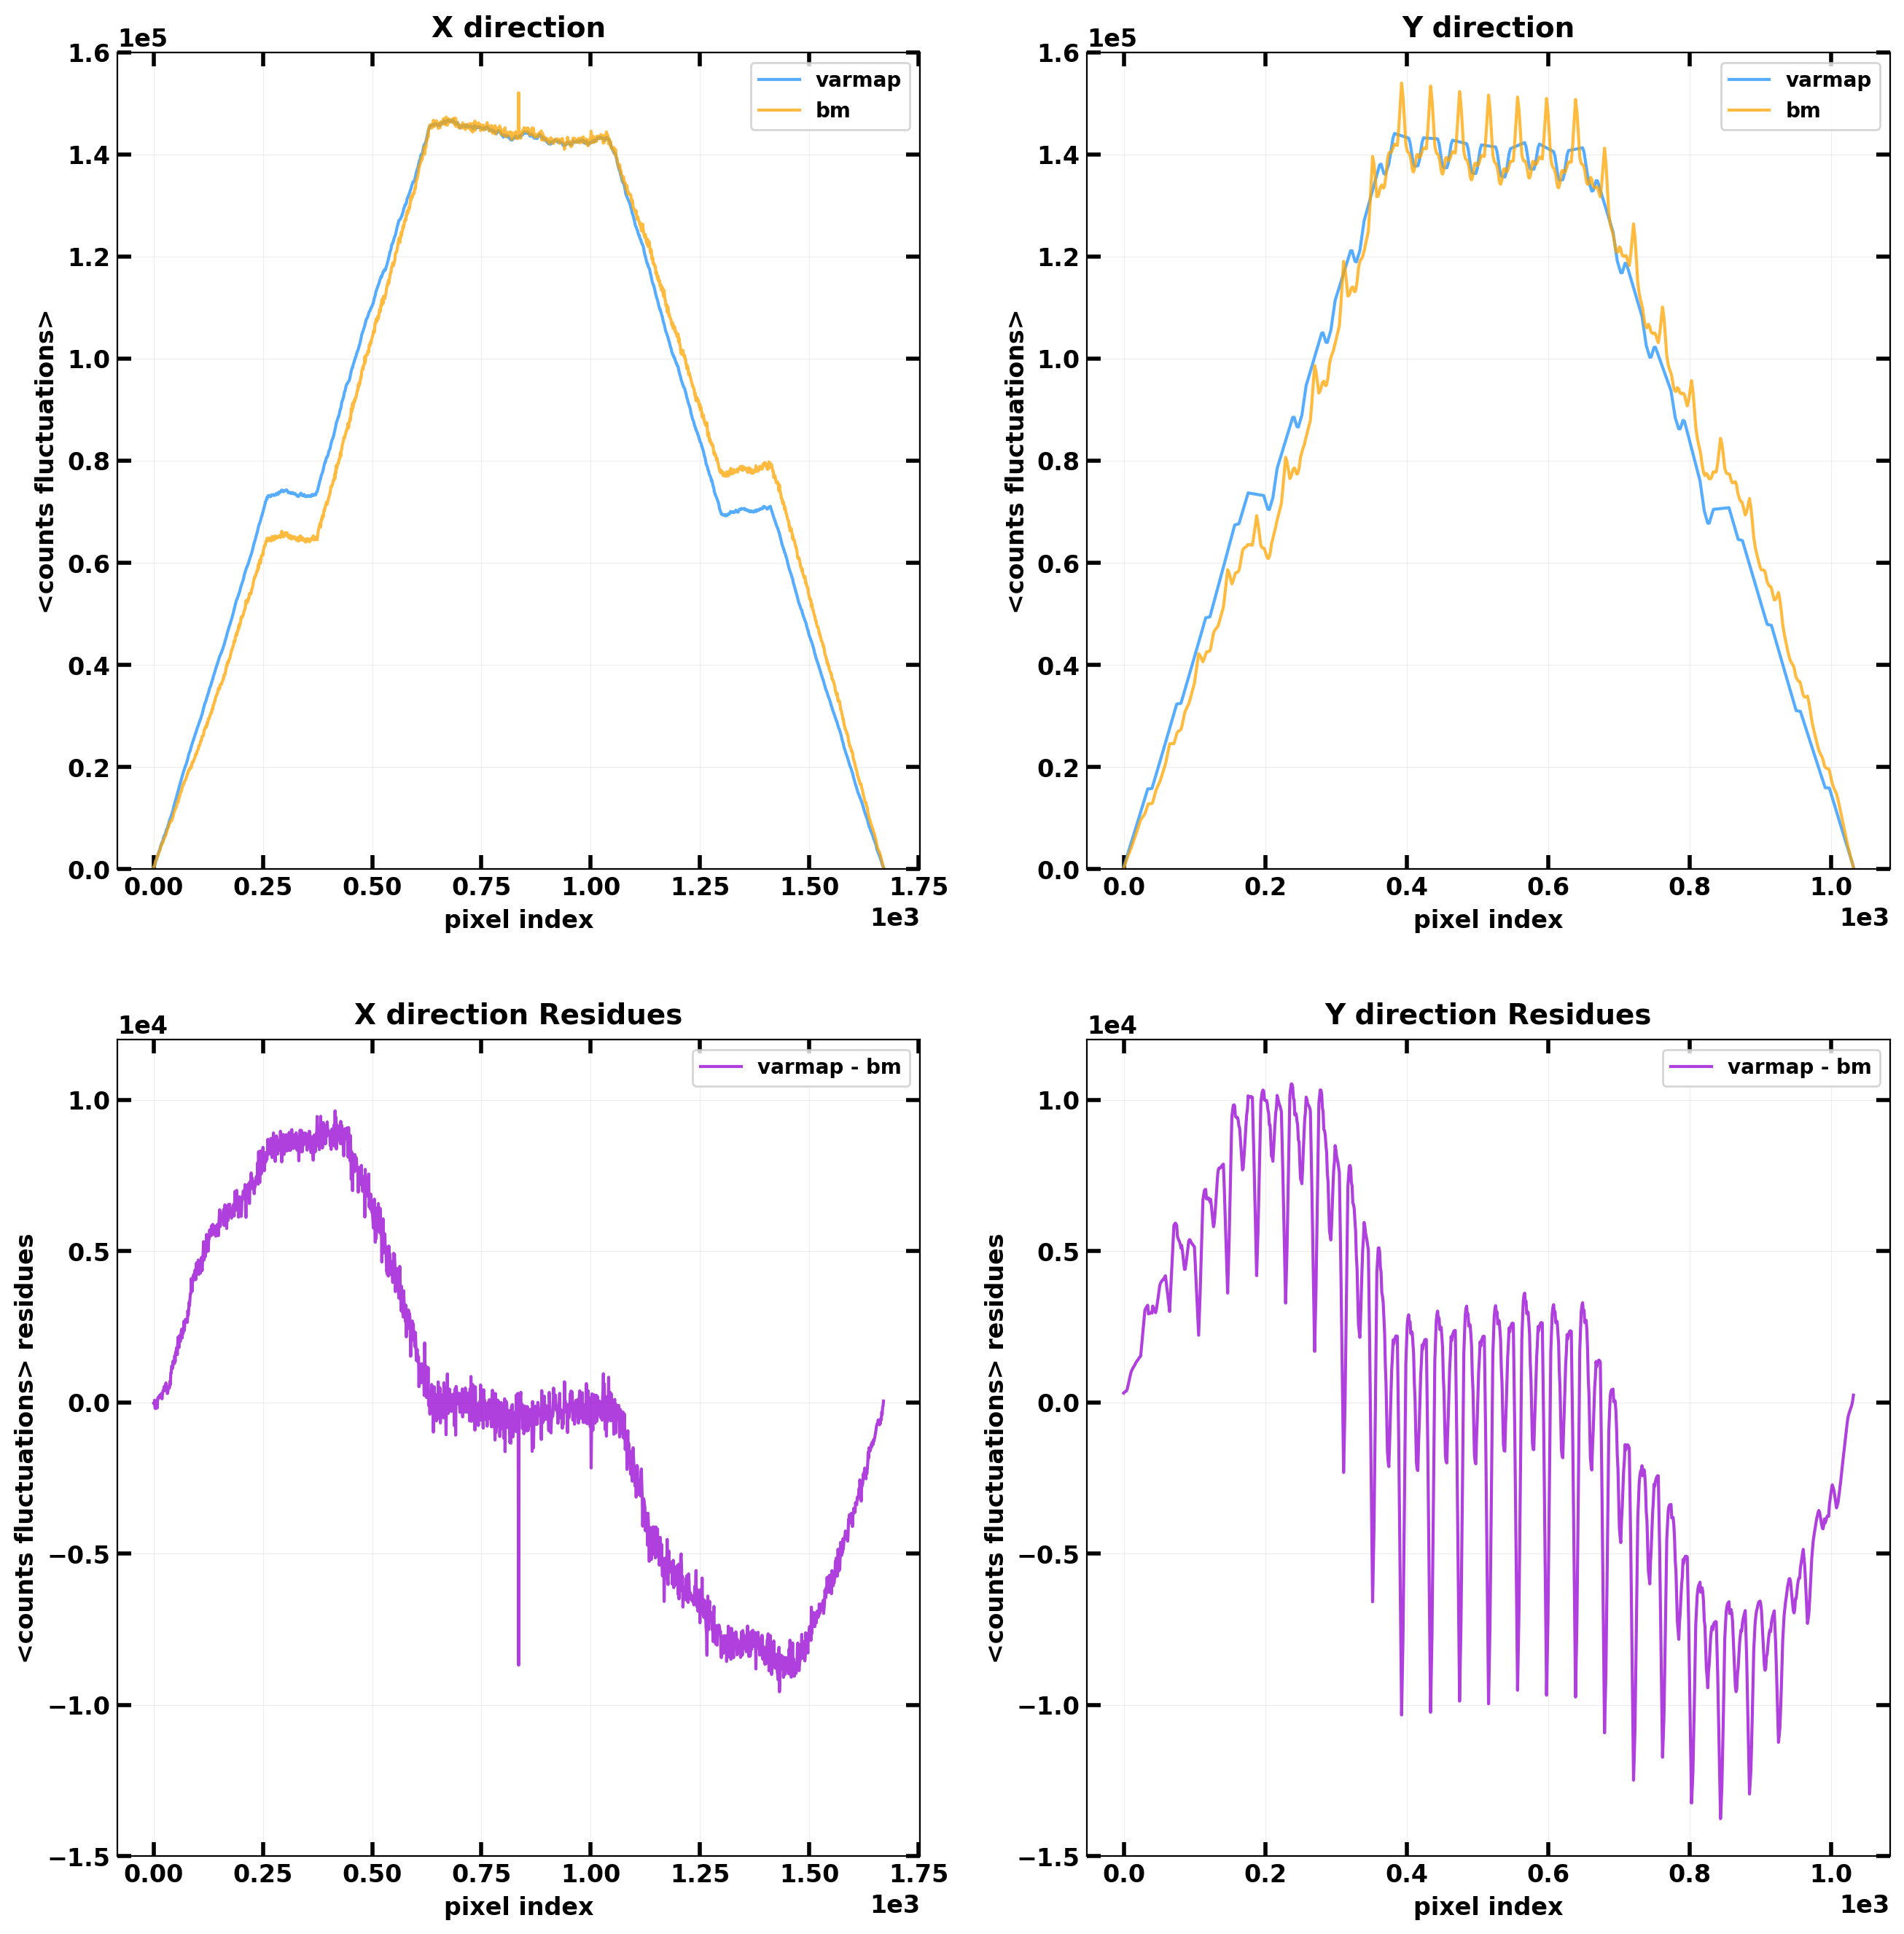

In [15]:
n, m = wfm.shape_sky

bm_varmap = variance(wfm, detector)

LIM = 2.5e-5
ds.image_plot(
    dmaps=ds.map4image(
        img=(varmap - bm_varmap) * 100 / varmap.sum(),
        title='Normalised Variance Residues',
        cbarlabel=r'residues [%]',
        img_kwargs={
            'cmap': 'bwr',
            'aspect': ASPECT,
            'vmin': -LIM,
            'vmax': LIM,
        },
    )
)


collapsed_var_x, collapsed_bmvar_x = map(
    lambda x: np.sum(x, axis=0) / n,
    (varmap, bm_varmap),
)
collapsed_var_y, collapsed_bmvar_y = map(
    lambda x: np.sum(x, axis=1) / m,
    (varmap, bm_varmap),
)

dmapx = ds.map4plot(
    arrs=(collapsed_var_x, collapsed_bmvar_x),
    title='X direction',
    ylabel='<counts fluctuations>',
    xlabel='pixel index',
    labels=('varmap', 'bm'),
    color=('DodgerBlue', 'Orange'),
    ylim=(0, 1.6e5),
)
dmapy = ds.map4plot(
    arrs=(collapsed_var_y, collapsed_bmvar_y),
    title='Y direction',
    ylabel='<counts fluctuations>',
    xlabel='pixel index',
    labels=('varmap', 'bm'),
    color=('DodgerBlue', 'Orange'),
    ylim=(0, 1.6e5),
)

dmapx_res = ds.map4plot(
    arrs=collapsed_var_x - collapsed_bmvar_x,
    title='X direction Residues',
    ylabel='<counts fluctuations> residues',
    xlabel='pixel index',
    labels=('varmap - bm'),
    color=('DarkViolet'),
    ylim=(-1.5e4, 1.2e4),
)
dmapy_res = ds.map4plot(
    arrs=collapsed_var_y - collapsed_bmvar_y,
    title='Y direction Residues',
    ylabel='<counts fluctuations> residues',
    xlabel='pixel index',
    labels=('varmap - bm'),
    color=('DarkViolet'),
    ylim=(-1.5e4, 1.2e4),
)

ds.plot(
    dmaps=(dmapx, dmapy, dmapx_res, dmapy_res),
    ncols=2,
    nrows=2,
)

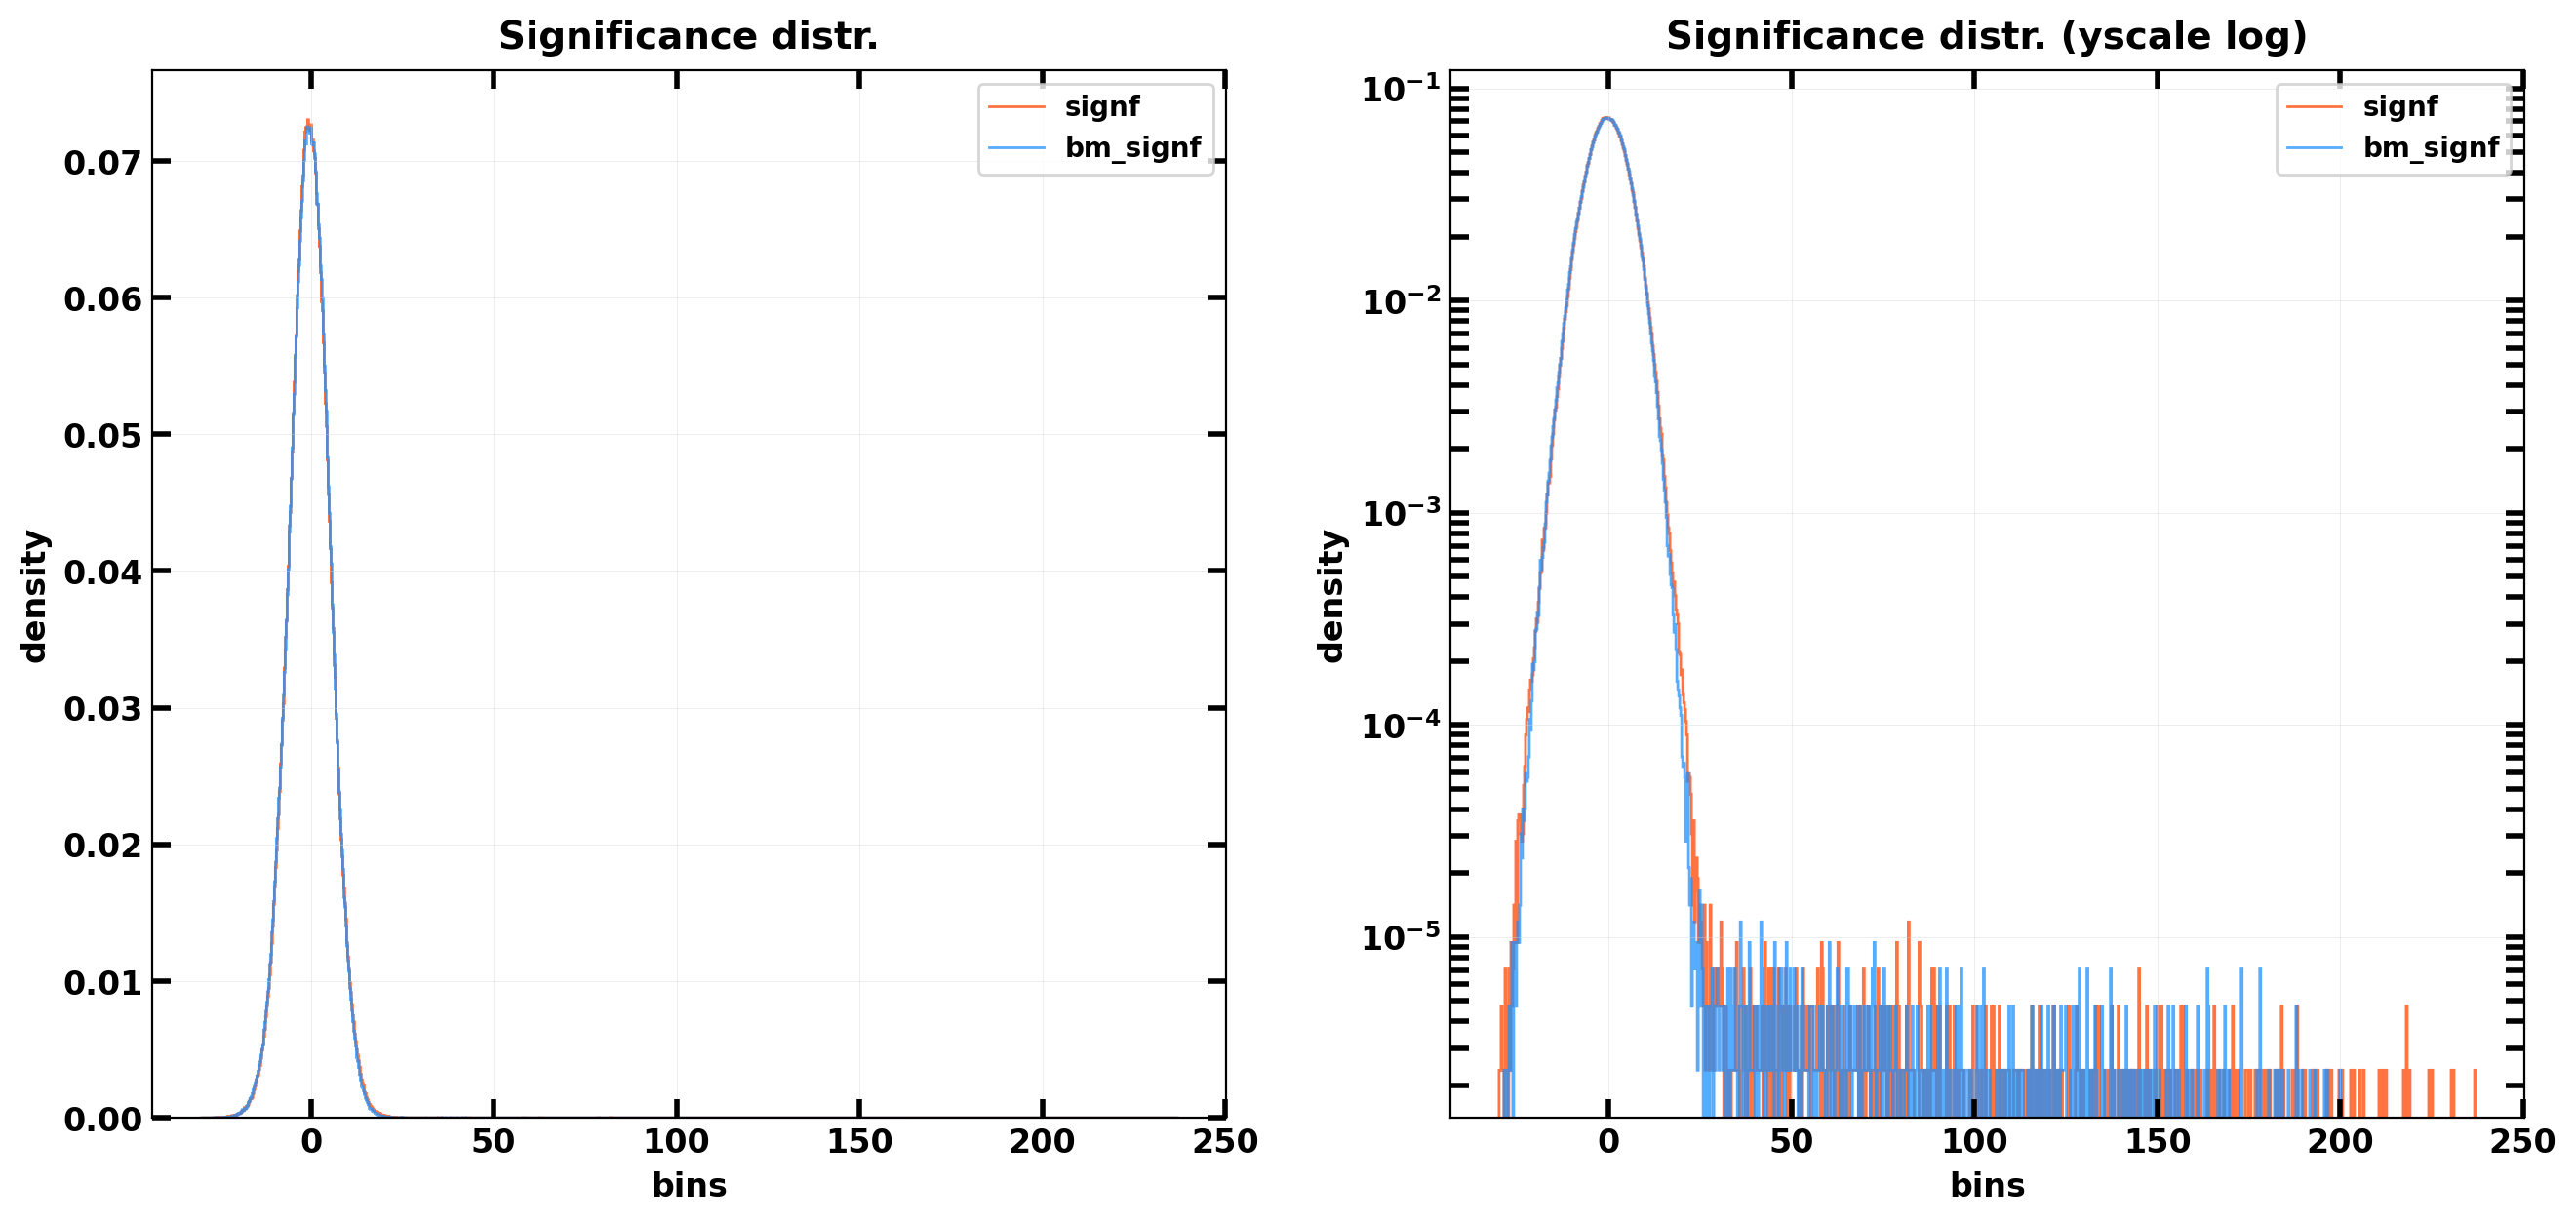

In [16]:
from bloodmoon.mask import snratio

bm_significance = ds.unframe(snratio(sky, bm_varmap), YLIM, XLIM)

assert (significance.shape == bm_significance.shape)

# plot significance distribution with the two variance maps
hist_signf, bins = np.histogram(significance, bins=1000, density=True)
hist_bm_signf, _ = np.histogram(bm_significance, bins=bins, density=True)


# plot distributions:
dmap1_snr = ds.map4plot(
    arrs=(
        hist_signf, hist_bm_signf,
    ),
    title='Significance distr.',
    xlabel='bins',
    ylabel='density',
    labels=(
        'signf', 'bm_signf',
    ),
    x=bins,
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(
        hist_signf, hist_bm_signf,
    ),
    title='Significance distr. (yscale log)',
    xlabel='bins',
    ylabel='density',
    labels=(
        'signf', 'bm_signf',
    ),
    x=bins,
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(dmaps=(dmap1_snr, dmap2_snr), ncols=2)